# Quantized CNN Training for Posture Classification (HGQ2-based QAT)

**Architecture**
- 3 QConv2D layers with QBatchNormalization
- Filter progression: [16, 16, 24]
- GlobalAveragePooling2D for efficiency
- Output: QDense(NUM_CLASSES) (logits output, no softmax)

**Quantization Strategy (HGQ2)**
- Fixed 8-bit quantization (`k0=0`) for both weights and activations
- `kbi` quantizer for weights (SAT_SYM overflow)
- `kif` quantizer for activations (WRAP overflow)
- Effective Bit-Operations (EBOPs) tracking for resource estimation

This notebook follows the HGQ2 best-practice patterns demonstrated in:
- [1] `small_jet_tagger.ipynb`
- [2] `larger_jet_tagger.ipynb`

**Hyperparameters**
- Learning rate: 0.001
- Batch size: 32
- Kernel size: (3, 3)
- L1 regularization: 1e-4
- Early stopping patience: 15
- Max epochs: 50

## Imports

In [25]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Keras 3
import keras

# TensorFlow
import tensorflow as tf

# Package imports
from bedposip.data import load_dataset, preprocess_data
from bedposip.model import (
    create_quantized_model,
    get_callbacks,
    train_model,
)
from bedposip.utils import (
    check_layer_trainable_params,
    plot_training_history,
    class_report_metric,
    save_model,
    inspect_quantization_bits, 
    plot_quantization_bits
)

# HGQ2 quantization-aware training
from hgq.config import QuantizerConfigScope, LayerConfigScope
from hgq.utils import trace_minmax

# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)

In [26]:
# Set random seed for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

# Constant number of postures
NUM_CLASSES = 3

# Check GPU
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data

### Loading

In [27]:
# Load datasets using package function
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset(type="raw")


Dataset shapes:
  Train: (119999, 64), labels: (119999,)
  Val:   (60000, 64), labels: (60000,)
  Test:  (120001, 64), labels: (120001,)


### Preprocessing

In [28]:
# Preprocess data using package function
(X_train, y_train, X_val, y_val, X_test, y_test, class_names) = preprocess_data(
    X_train, y_train, X_val, y_val, X_test, y_test,
    num_classes=NUM_CLASSES,
)

Label encoding:
  lateral_L -> 0
  lateral_R -> 1
  supine -> 2

One-hot encoded shape: 3

Reshaped data:
  Train: (119999, 8, 8, 1)
  Val:   (60000, 8, 8, 1)
  Test:  (120001, 8, 8, 1)

Data range: [0.0000, 233.4754]
Data dtype: float32


## Configuration

In [29]:
# Define callbacks using package function
callbacks = get_callbacks(model_name='qat', patience=30, track_ebops=True)

Callbacks configured:
  - EarlyStopping
  - ReduceLROnPlateau
  - ModelCheckpoint
  - FreeEBOPs


## Quantized Model

HGQ2 Quantization Configuration

- **`kbi` quantizer** for weights: Fixed 8-bit (4 integer + 4 fractional) with symmetric saturation overflow
- **`kif` quantizer** for activations (datalane): Fixed 8-bit (4 integer + 4 fractional) with wrap-around overflow
- **No softmax in the model**: The output layer produces raw logits

> "QSoftmax is bit-accurate, but it can give exactly zero now: xentropy will diverge and thus USE WITH CAUTION. For classification, it is recommended to NOT to use softmax in the model, but to use it in the loss function"

This approach follows the best practices demonstrated in [1] `small_jet_tagger.ipynb` and [2] `larger_jet_tagger.ipynb`.

In [30]:
from hgq.constraints import Max

with (
    QuantizerConfigScope(place='all', default_q_type='kbi', overflow_mode='SAT_SYM'),
    QuantizerConfigScope(
        place='weight',
        # bc=Max(16),
        # ic=Max(4),
        #i0=2, #f0=4, #bc=Max(16),
        default_q_type='kif', overflow_mode='WRAP'
    ),
    QuantizerConfigScope(
        place='datalane',
        fc=Max(8),
        ic=Max(8),
        #i0=4, f0=4, #fc=Max(8), ic=Max(8), #
        default_q_type='kif', overflow_mode='WRAP'
    ),
    LayerConfigScope(enable_ebops=True, beta0=1e-7),
):
    model_qat = create_quantized_model(num_classes=NUM_CLASSES)
    model_qat.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.CategoricalCrossentropy(from_logits=True),
        metrics=['accuracy'],
    )

model_qat.summary()
check_layer_trainable_params(model_qat)

Model: "posture_classifier_qat"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_1 (QConv2D)               │ (None, 6, 6, 16)       │           772 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (QBatchNormalization) │ (None, 6, 6, 16)       │         1,892 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (Activation)         │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_2 (QConv2D)               │ (None, 4, 4, 16)       │        10,948 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (QBatchNormalization) │ (None, 4, 4, 16)       │           932 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_2 (Activation)         │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qconv_3 (QConv2D)               │ (None, 2, 2, 24)       │        14,596 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_3 (QBatchNormalization) │ (None, 2, 2, 24)       │           532 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_3 (Activation)         │ (None, 2, 2, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_1 (QDense)               │ (None, 42)             │        16,588 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_1                      │ (None, 42)             │           550 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ qdense_2 (QDense)               │ (None, 64)             │        11,138 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_2                      │ (None, 64)             │           836 │
│ (QBatchNormalization)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (QDense)                 │ (None, 3)              │           976 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,760 (188.38 KB)

 Trainable params: 28,901 (112.89 KB)

 Non-trainable params: 30,859 (75.48 KB)

### Training

Epoch 1/500


I0000 00:00:1778278695.777004  168178 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_861883__.110


47/59 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4293 - loss: 1.1556 

I0000 00:00:1778278706.698571  168180 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_861883__.110


59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.4424 - loss: 1.1323
Epoch 1: val_loss improved from None to 1.19472, saving model to best_qat_model.keras

Epoch 1: finished saving model to best_qat_model.keras
59/59 ━━━━━━━━━━━━━━━━━━━━ 33s 265ms/step - accuracy: 0.5016 - loss: 1.0282 - val_accuracy: 0.3514 - val_loss: 1.1947 - learning_rate: 0.0010 - ebops: 85950.0000
Epoch 2/500
50/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6232 - loss: 0.8382
Epoch 2: val_loss did not improve from 1.19472
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6347 - loss: 0.8193 - val_accuracy: 0.3074 - val_loss: 2.6813 - learning_rate: 0.0010 - ebops: 86862.0000
Epoch 3/500
47/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6610 - loss: 0.7728
Epoch 3: val_loss did not improve from 1.19472
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6240 - loss: 1.2858 - val_accuracy: 0.3353 - val_loss: 2.2476 - learning_rate: 0.0010 - ebops: 90476.0000
Epoch 4/500
46/59 ━━━━━━━━━━━━━━━━━━━━ 

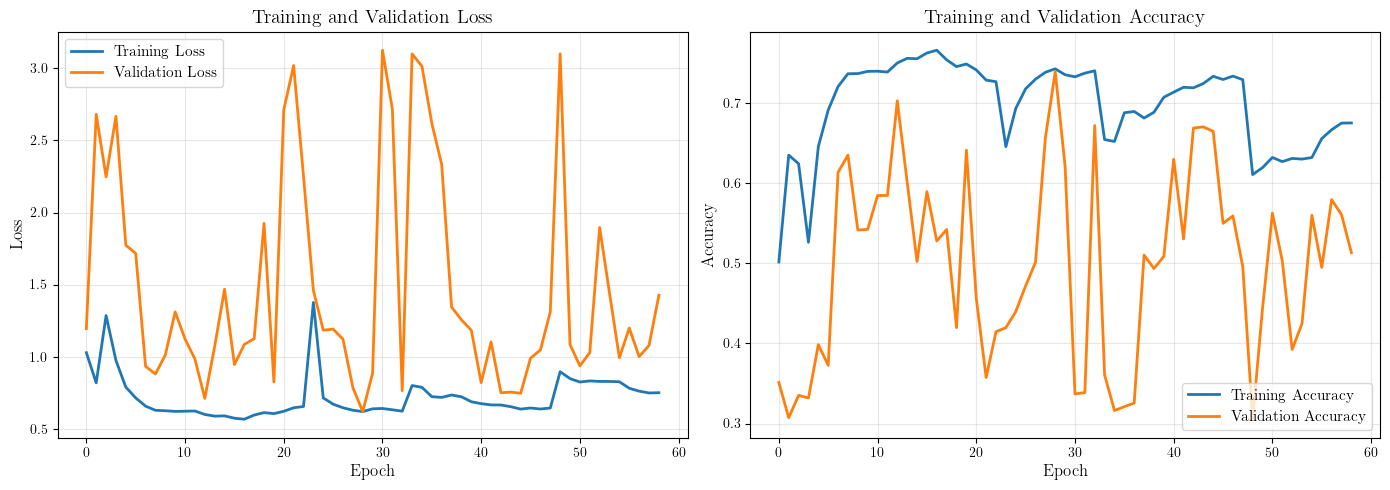

In [31]:
history_qat = train_model(model_qat, X_train,y_train, X_val, y_val, callbacks, batch_size=2048, epochs=500) # Batch according to HGQ article
plot_training_history(history_qat, model_name='posture_classifier_qat', save=True)

## Model Evaluation

In [32]:
class_report_metric(model_qat, X_test, y_test, class_names)


Accuracy Report for `posture_classifier_qat`:
  Loss: 0.6242
  Accuracy: 73.68%

Classification Report for `posture_classifier_qat`:
              precision    recall  f1-score   support

   lateral_L     0.7661    0.6918    0.7271     40000
   lateral_R     0.6833    0.8295    0.7493     40000
      supine     0.7806    0.6892    0.7321     40001

    accuracy                         0.7368    120001
   macro avg     0.7433    0.7368    0.7361    120001
weighted avg     0.7433    0.7368    0.7361    120001



In [33]:
# Inspect learned quantization bit-widths
# bits_info = inspect_quantization_bits(model_qat, report=True)

# plot_quantization_bits(model_qat, bits_info=bits_info, save=False)


In [34]:
# From larger_jet_tagger

# When using `WRAP` overflow mode for activations (datalane), HGQ2 needs to know the min/max values of each layer's activations to determine the required integer bits. 
trace_minmax(model_qat, X_train, batch_size=2048)
ebops = trace_minmax(model_qat, X_val, batch_size=2048, reset=False)

lut_pred = np.exp(0.985 * np.log(ebops))
dsp_pred = (ebops - lut_pred) / 55

print("Resource Estimation Report")
print("="*40)
print(f"\nEBOPs: {ebops} \nLUTs: {lut_pred:.0f} \nDSPs: {dsp_pred:.0f}")

Resource Estimation Report

EBOPs: 77170 
LUTs: 65183 
DSPs: 218


In [35]:
# Inspect learned quantization bit-widths
bits_info = inspect_quantization_bits(model_qat, report=True)

# plot_quantization_bits(model_qat, bits_info=bits_info, save=False)


Quantization Bit-width Report:
pressure_map: InputLayer (no quantizers)

qconv_1 (QConv2D):
  iq: bits=9.91, fbits=9.91, type=kif
  kq: bits=0.28, fbits=0.42, type=kif

bn_conv_1 (QBatchNormalization):
  iq: bits=5.91, fbits=6.41, type=kif
  kq: bits=2.12, fbits=2.12, type=kif
  bq: bits=3.69, fbits=4.69, type=kbi
conv_act_1: Activation (no quantizers)

qconv_2 (QConv2D):
  iq: bits=1.94, fbits=1.94, type=kif
  kq: bits=0.22, fbits=0.34, type=kif

bn_conv_2 (QBatchNormalization):
  iq: bits=5.53, fbits=6.53, type=kif
  kq: bits=2.94, fbits=2.94, type=kif
  bq: bits=4.00, fbits=5.00, type=kbi
conv_act_2: Activation (no quantizers)

qconv_3 (QConv2D):
  iq: bits=4.78, fbits=4.78, type=kif
  kq: bits=0.25, fbits=0.39, type=kif

bn_conv_3 (QBatchNormalization):
  iq: bits=5.59, fbits=6.59, type=kif
  kq: bits=2.21, fbits=2.21, type=kif
  bq: bits=4.00, fbits=5.00, type=kbi
conv_act_3: Activation (no quantizers)
flatten_2: Flatten (no quantizers)

qdense_1 (QDense):
  iq: bits=4.50, fbits=

## Model Saving

In [36]:
# Save model
save_model(model_qat, output_dir='output')


Model saved to: output/posture_classifier_qat.keras

Verification:
  Loaded successfully: True
  Model name: posture_classifier_qat
  Total parameters: 59,760
